In [1]:
# where is the event in the spring neap tide cycle

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path

import os, sys
import glob

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as tkr

import cmocean
#import seaborn as sns
#sns.set_style('ticks')

from scipy import stats
from scipy.stats import percentileofscore

from datetime import datetime, timedelta
from vtools.functions.filter import cosine_lanczos
from vtools.data.vtime import days, hours, minutes
from vtools.functions.unit_conversions import ec_psu_25c



/global/home/users/jennaisrael/.conda/envs/schimpy/lib/python3.7/site-packages/dask/dataframe/utils.py:15: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


In [3]:
#function comes from schimpy metricsplot.py script https://github.com/CADWRDeltaModeling/schimpy/blob/master/schimpy/metricsplot.py
def filter_timeseries(tss, cutoff_period=hours(40)):
    filtered = []
    ts=tss #try removing the loop for now
    if ts is None:
        filtered.append(None)
    else:
        #print(ts)
        ts_filtered = cosine_lanczos(ts, cutoff_period=cutoff_period)
        ts_filtered.filtered = 'cosine_lanczos'
    return ts_filtered

In [4]:
#load point reyes
colnames=['datetime','elev[m]']
dtformat = '%Y-%m-%dT%H:%M:%S'
#pryc=pd.read_csv('/global/scratch/users/jennaisrael/climate_data_processing/identify_stp/pryc1default_elev_screened_2021.csv', skiprows=73)
dtformat = '%Y-%m-%dT%H:%M'
pryc=pd.read_csv('/global/scratch/users/jennaisrael/time_varying_data/tide_gauge_data/noaa_9415020_9415020_water_level_1950_2021.csv', 
                 skiprows=9,header=0,
                 names=['datetime','elev[m]','sigma','verified','F','R','L','quality'])
pryc['datetime']=pd.to_datetime(pryc['datetime'],format=dtformat)#.asfreq('15min')
pryc.set_index("datetime",inplace=True)
# pryc=pryc.rename(columns={"value": "elev[m]"})
pryc

,elev[m],sigma,verified,F,R,L,quality
datetime,,,,,,,
1995-12-01 00:06:00,NaN,NaN,1,1,1,1,p
1995-12-01 00:12:00,NaN,NaN,1,1,1,1,p
1995-12-01 00:18:00,NaN,NaN,1,1,1,1,p
1995-12-01 00:24:00,NaN,NaN,1,1,1,1,p
1995-12-01 00:30:00,NaN,NaN,1,1,1,1,p
...,...,...,...,...,...,...,...
2021-10-01 23:30:00,0.479,0.033,0,0,0,0,v
2021-10-01 23:36:00,0.467,0.052,0,0,0,0,v
2021-10-01 23:42:00,0.451,0.034,0,0,0,0,v


In [5]:
pr = pryc.drop(columns=['sigma','verified','F', 'R','L','quality']).asfreq('6min')
pr

,elev[m]
datetime,
1995-12-01 00:06:00,NaN
1995-12-01 00:12:00,NaN
1995-12-01 00:18:00,NaN
1995-12-01 00:24:00,NaN
1995-12-01 00:30:00,NaN
...,...
2021-10-01 23:30:00,0.479
2021-10-01 23:36:00,0.467
2021-10-01 23:42:00,0.451


In [6]:
pr_filt=filter_timeseries(pr)
pr_filt

,elev[m]
datetime,
1995-12-01 00:06:00,NaN
1995-12-01 00:12:00,NaN
1995-12-01 00:18:00,NaN
1995-12-01 00:24:00,NaN
1995-12-01 00:30:00,NaN
...,...
2021-10-01 23:30:00,NaN
2021-10-01 23:36:00,NaN
2021-10-01 23:42:00,NaN


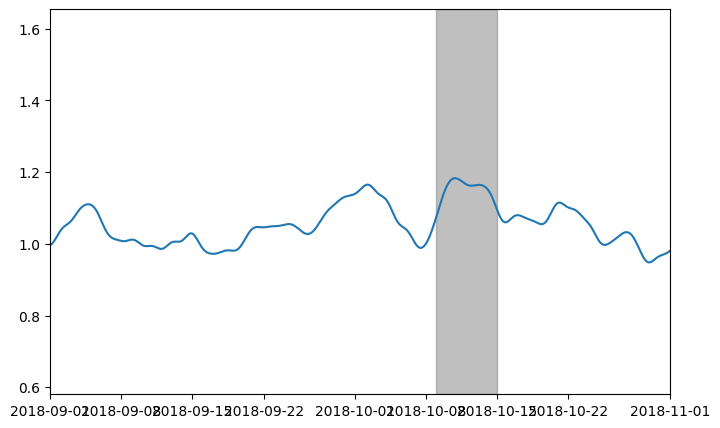

In [7]:
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(pr_filt)
ax.set_xlim(pd.to_datetime('2018-09-01'),pd.to_datetime('2018-11-01'))
ax.axvspan(pd.to_datetime('2018-10-9'),pd.to_datetime('2018-10-15'), color="grey", alpha=0.5)

In [8]:
# try plotting <eta-<eta> > per Eli's suggestion

In [18]:
n=filter_timeseries(pr['elev[m]']-pr_filt['elev[m]'])
te=filter_timeseries((pr['elev[m]']-pr_filt['elev[m]'])**2)

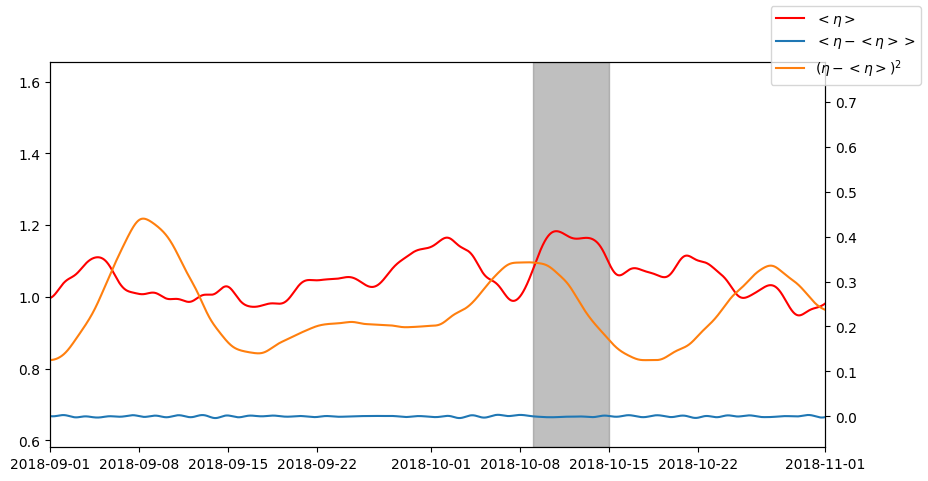

In [22]:
fig, ax = plt.subplots(figsize=(10,5),sharex=True)
ax.plot(pr_filt, label=r'$< \eta >$',color='r')
ax2=ax.twinx()
ax2.plot(n,label=r'$< \eta - < \eta > >$')
ax2.plot(te, label=r'$( \eta - < \eta > )^2$')

ax.set_xlim(pd.to_datetime('2018-09-01'),pd.to_datetime('2018-11-01'))
ax.axvspan(pd.to_datetime('2018-10-9'),pd.to_datetime('2018-10-15'), color="grey", alpha=0.5)
fig.legend()
fig.savefig('./tidal_energy_subtide_fall_2018.png')